# A-RoF transmission

In [1]:
import sys
from pathlib import Path

file_path    = str(Path.cwd())
project_path = str(Path.cwd().parent)

sys.path.append(project_path)

In [2]:
import pickle 
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal             import welch, firwin, hilbert
from scipy.constants          import pi
from tqdm.notebook            import tqdm
from tabulate                 import tabulate

from optic.comm.ofdm          import modulateOFDM, demodulateOFDM
from optic.comm.modulation    import modulateGray
from optic.models.channels    import linearFiberChannel
from optic.models.devices     import mzm, photodiode
from optic.comm.metrics       import fastBERcalc, calcEVM
from optic.dsp.core           import pnorm, signal_power, finddelay, decimate, upsample, clockSamplingInterp
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters, dBm2W

from dpd.utils                import power_amplifier, calcACLR
from dpd.plots                import calc_per_carrier

In [3]:
font = {'size':16}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - Geração do Sinal OFDM

In [4]:
# Parâmetros de modulação
modOrder = 64                          # Ordem da modulação
modType  = 'qam'                       # Tipo de modulação
SpS = 102                              # Amostras por símbolo

# Parâmetros OFDM
paramOFDM = parameters()
paramOFDM.bw  = 100e6                  # Channel bandwidth
paramOFDM.scs = 30e3                   # Subcarrier spacing
paramOFDM.G   = 288                    # Tamanho do prefixo cíclico                 
paramOFDM.hermitSymmetry = False      
paramOFDM.SpS = SpS
paramOFDM.returnChannel = False

if paramOFDM.bw == 100e6 and paramOFDM.scs == 30e3:
    RBs = 273
    paramOFDM.Nfft = 2**12

elif paramOFDM.bw == 50e6 and paramOFDM.scs == 30e3:
    RBs = 133
    paramOFDM.Nfft  = 2**12

elif paramOFDM.bw == 10e6 and paramOFDM.scs == 30e3:
    RBs = 24
    paramOFDM.Nfft = 2**9

elif paramOFDM.bw == 400e6 and paramOFDM.scs == 480e3:
    RBs = 66
    paramOFDM.Nfft = 2**11

elif paramOFDM.bw == 100e6 and paramOFDM.scs == 480e3:
    RBs = 17
    paramOFDM.Nfft = 2**12

elif paramOFDM.bw == 400e6 and paramOFDM.scs == 1e6:
    RBs = 33
    paramOFDM.Nfft = 2**11

else:
    print("Check for error in parameters definition")

guard_band_SCs = int((paramOFDM.Nfft - RBs*12) / 2)

In [5]:
if paramOFDM.hermitSymmetry:
    Ns = paramOFDM.Nfft//2 - 1
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([], dtype = np.int64)
else:
    Ns = paramOFDM.Nfft
    GB_in  = np.arange(0, guard_band_SCs, dtype = np.int64)
    GB_out = np.arange(Ns -  guard_band_SCs, Ns, dtype = np.int64)
    
    paramOFDM.nullCarriers  = np.concatenate((GB_in, np.array([paramOFDM.Nfft//2], dtype = np.int64), GB_out))
    paramOFDM.pilotCarriers = np.linspace(guard_band_SCs, Ns - guard_band_SCs - 1, 32, dtype = np.int64)

Np = paramOFDM.pilotCarriers.size     # N° de subportadoras piloto
Nz = paramOFDM.nullCarriers.size      # N° de subportadoras nulas
Ni = Ns - Np - Nz                     # N° de subportadoras de informação

Rs = paramOFDM.scs * paramOFDM.Nfft   # Taxa de transmissão de símbolos
Fs = Rs * SpS                         # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
numOFDMframes = 10
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(modOrder))))

symbTx = modulateGray(bits, modOrder, modType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [6]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

t = np.arange(0, sigTx.size)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

In [7]:
table = [['Grandeza', 'Parâmetro', 'Valor'],
         ['Taxa de amostragem', 'Fs', f'{Fs*1e-9:.2f} Gsamples/s'],
         ['Taxa de símbolos', 'Rs', f'{Rs*1e-9:.2f} Gsymb/s'],
         ['Banda do sinal RF', 'Bw', f'{paramOFDM.bw*1e-6:.2f} MHz'],
         ['Ordem da constelação', 'M', f'{modOrder}'],
         ['Tamanho da FFT', 'Nfft', f'{paramOFDM.Nfft}'],
         ['Tamanho do prefixo cíclico', 'G', f'{paramOFDM.G}'],
         ['Num. port. de informação', 'Ns', f'{Ni}'],
         ['Num. port. piloto', 'Np', f'{Np}'],
         ['Num. port. nulas', 'Nz', f'{Nz}'],
         ['Espaçamento entre subportadoras', 'Delta_f', f'{(Rs/paramOFDM.Nfft)*1e-3:.2f} kHz'],
         ['Duração do símbolo OFDM', 'T_symb', f'{1e6*t_symb:.2f} us'],
         ['Duração do prefixo cíclico', 'T_CP', f'{1e6*t_CP:.2f} us'] ]

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═════════════════════════════════╤═════════════╤══════════════════╕
│ Grandeza                        │ Parâmetro   │ Valor            │
╞═════════════════════════════════╪═════════════╪══════════════════╡
│ Taxa de amostragem              │ Fs          │ 12.53 Gsamples/s │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de símbolos                │ Rs          │ 0.12 Gsymb/s     │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Banda do sinal RF               │ Bw          │ 100.00 MHz       │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Ordem da constelação            │ M           │ 64               │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho da FFT                  │ Nfft        │ 4096             │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho do prefixo cíclico      │ G           │ 288              │
├─────────────────────────────────

In [8]:
## Parametrização dos dispositivos

# Parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi*0.5
paramMZM.Pin_OF = 10

# Parâmetros do canal óptico
paramChannel = parameters()
paramChannel.L = 25
paramChannel.alpha = 0.2
paramChannel.D = 16
paramChannel.Fc = 193.1e12
paramChannel.Fs = Fs

#
paramRF = parameters()
paramRF.fc_e = 3.55e9
paramRF.Pin_RF = 17
paramRF.Pin_PA = 5

# Parâmetros do fotodiodo
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

ACLR = -44.692 dB


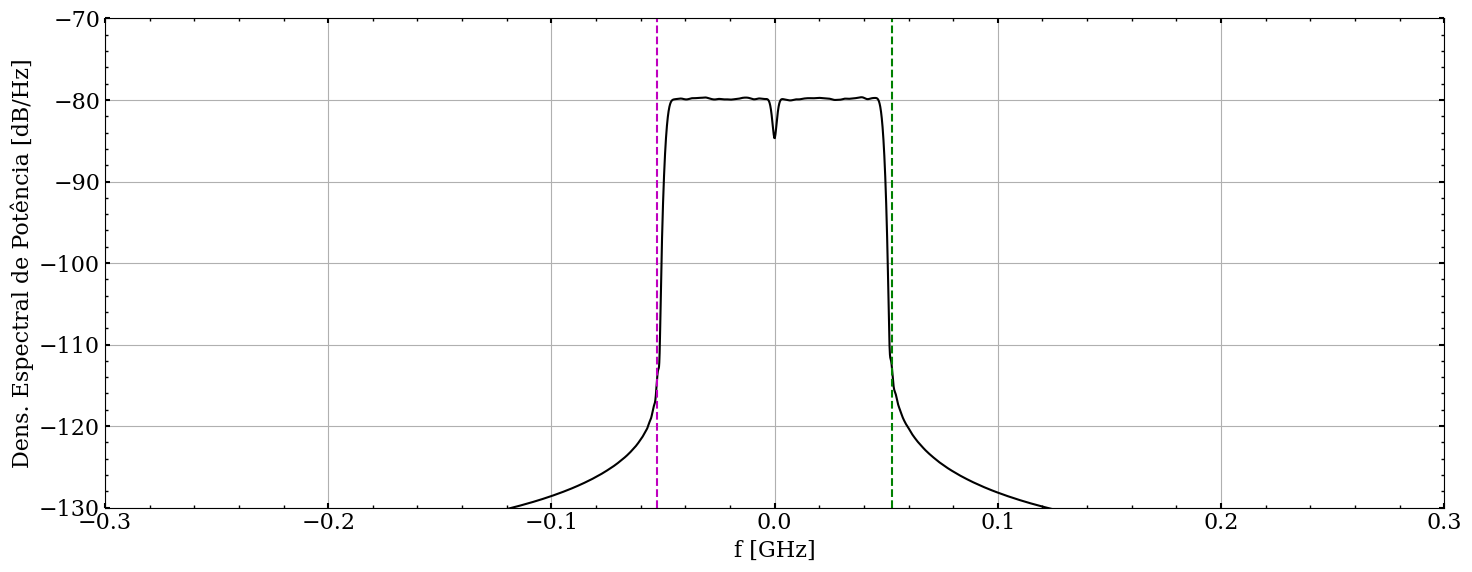

In [29]:
fig, axs = plt.subplots(1, 1, figsize = (15, 6))

freq, P_sigTx = welch(pnorm(sigTx)[0::SpS//4], fs = 4*Rs, nfft = 16*1024, return_onesided = False)
print(f"ACLR = {calcACLR(P_sigTx, freq, paramOFDM.bw/2, 2.5e6):.3f} dB")

axs.plot(freq/1e9, 10*np.log10(P_sigTx), color = "k")
axs.set_xlabel("f [GHz]")
axs.set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs.set_xlim(-paramOFDM.bw/1e9 - 0.2, paramOFDM.bw/1e9 + 0.2)
axs.set_ylim(-130,-70)
axs.grid(True)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs.axvline(1e-9*(paramOFDM.bw/2 + 2.5e6), ls = "--", color = "g")
axs.axvline(-1e-9*(paramOFDM.bw/2 + 2.5e6), ls = "--", color = "m")

plt.tight_layout()
plt.show()

### 2 Canal RoF

#### 2.1 Sinal RF

In [10]:
sigTx_RF = np.real( sigTx * np.exp(1j*2*pi*paramRF.fc_e*t) )

gain_pre_MZM = 10**( np.log10(dBm2W(paramRF.Pin_RF)/signal_power(sigTx_RF))/2)
sigTx_RF *= gain_pre_MZM
sigTx_RF = np.clip(sigTx_RF, -paramMZM.Vpi/2, paramMZM.Vpi/2)

print(f"Power at MZM's input: {10*np.log10(1e3*signal_power(sigTx_RF)):.3f} dBm")

Power at MZM's input: 17.000 dBm


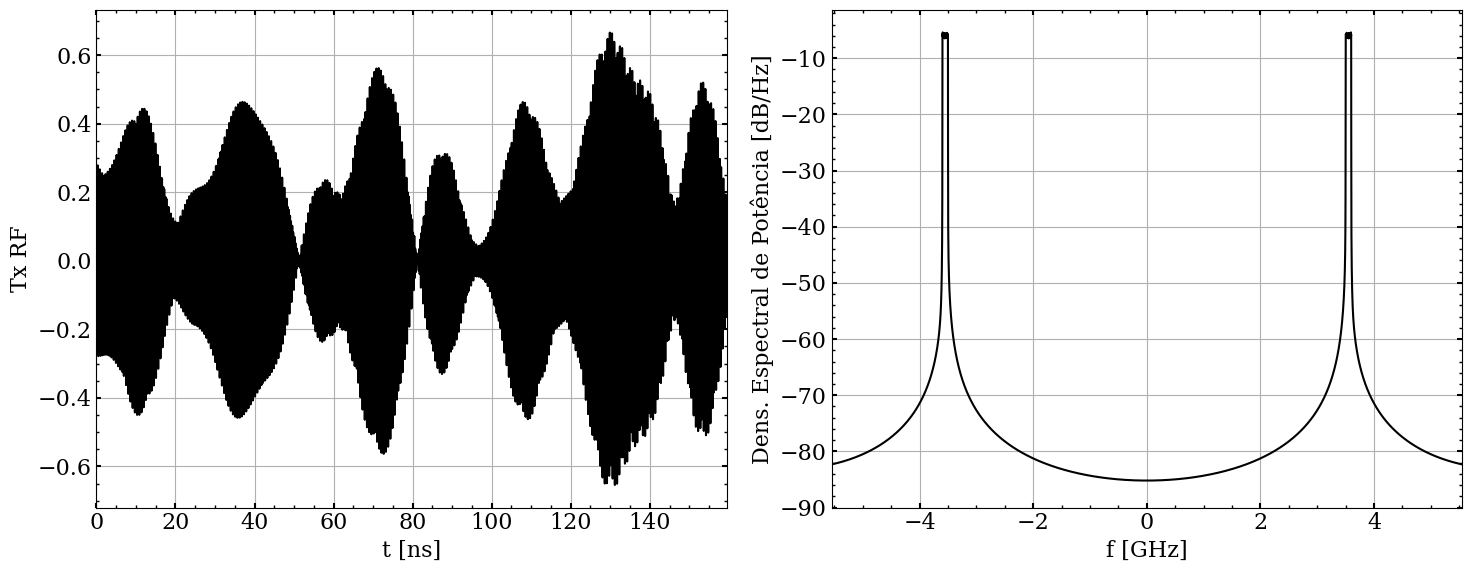

In [11]:

indx = np.arange(0, 2000)

fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, sigTx_RF[indx], "k")
axs[1].psd(sigTx_RF, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("Tx RF")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-paramRF.fc_e/1e9 - 2, paramRF.fc_e/1e9 + 2)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.2 Sinal óptico

In [12]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF.size)
sigTxo = mzm(Ai, sigTx_RF, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo = np.sqrt(signal_power(sigTxo))*pnorm(firFilter(hopt_tx, sigTxo))

sigRxo = linearFiberChannel(sigTxo, paramChannel)

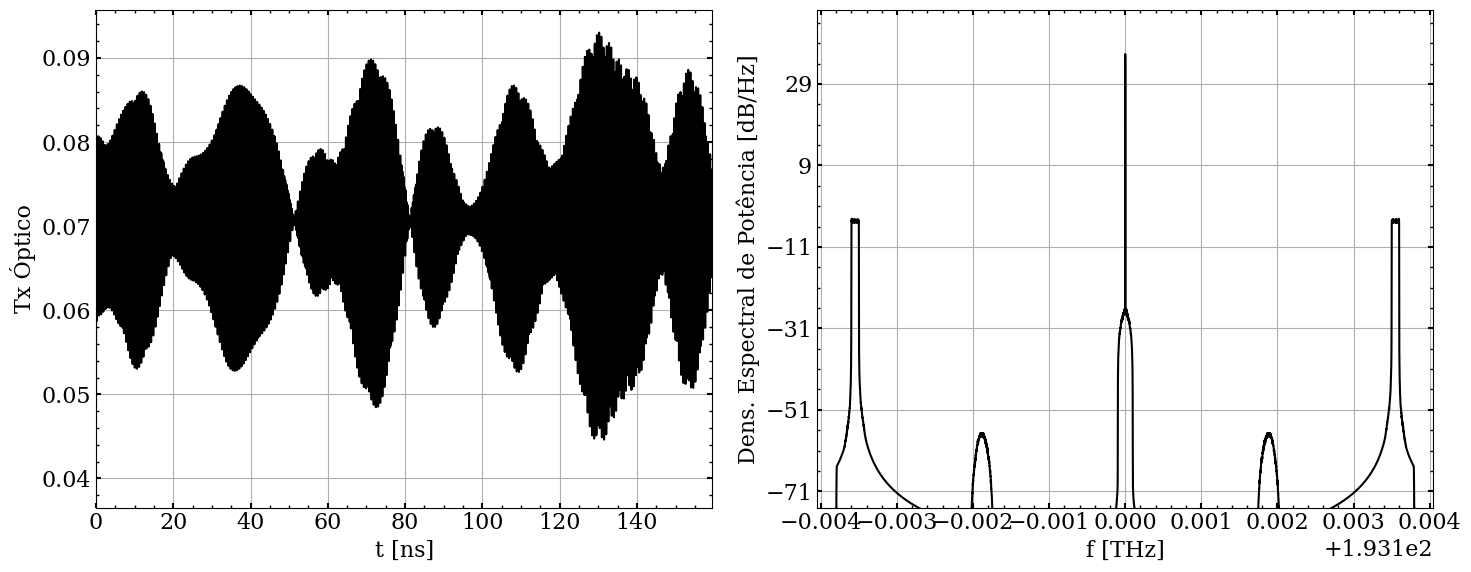

In [13]:
indx = np.arange(0, 2000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, sigTxo[indx], "k")
axs[1].psd(np.abs(sigTxo), Fs = Fs/1e12, Fc = paramChannel.Fc/1e12, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("Tx Óptico")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-(paramRF.fc_e + 5*paramOFDM.bw - paramChannel.Fc)/1e12, (paramRF.fc_e + 5*paramOFDM.bw + paramChannel.Fc)/1e12)
axs[1].set_ylim(-75)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.3 Sinal elétrico (fotocorrente)

In [14]:
I_Rx = photodiode(sigRxo, paramPD)
I_Rx -= I_Rx.mean()

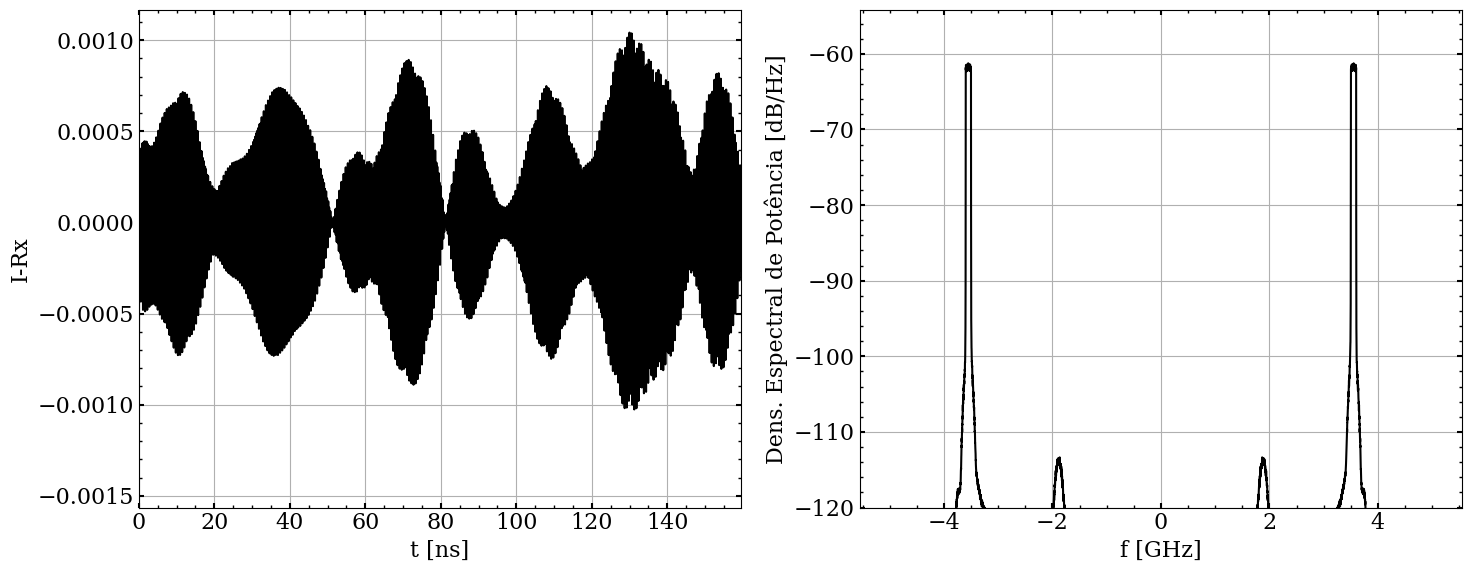

In [15]:

indx = np.arange(0, 2000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, I_Rx[indx], "k")
axs[1].psd(I_Rx, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("I-Rx")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(- paramRF.fc_e/1e9 - 2,  paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-120)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-120, -50, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.4 Sinal elétrico pós-FPF

In [16]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF = firFilter(hbp_RF, I_Rx)

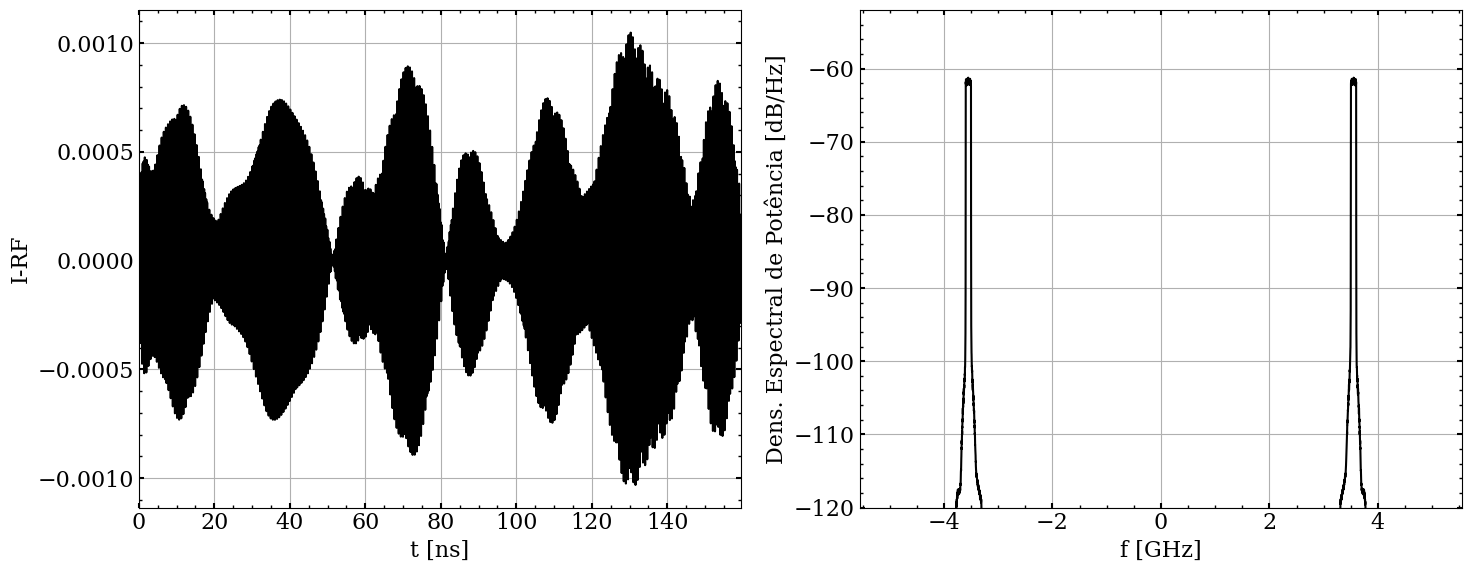

In [17]:

indx = np.arange(0, 2000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, I_RF[indx], "k")
axs[1].psd(I_RF, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("I-RF")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(- paramRF.fc_e/1e9 - 2,  paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-120)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-120, -50, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.5 Sinal elétrico pós-PA

In [18]:
sigRx = hilbert(I_RF)*np.exp(-1j*2*pi*paramRF.fc_e*t)

alpha = 0 # dB
theta = 0 # degrees

IQ_imb = 10**(alpha / 10) * np.exp(1j*theta * pi/180)
sigRx = sigRx.real + 1j*sigRx.imag * IQ_imb

gain_pre_PA = 10**( np.log10(dBm2W(paramRF.Pin_PA)/signal_power(sigRx))/2)
sigRx *= gain_pre_PA

sigRx = power_amplifier(sigRx)

sigRx_PA = sigRx.copy()
sigRx_PA = pnorm(sigRx_PA)

numtaps = 4096
hlp = firwin(numtaps, Rs/1.75, fs = Fs)
sigRx = firFilter(hlp, sigRx)

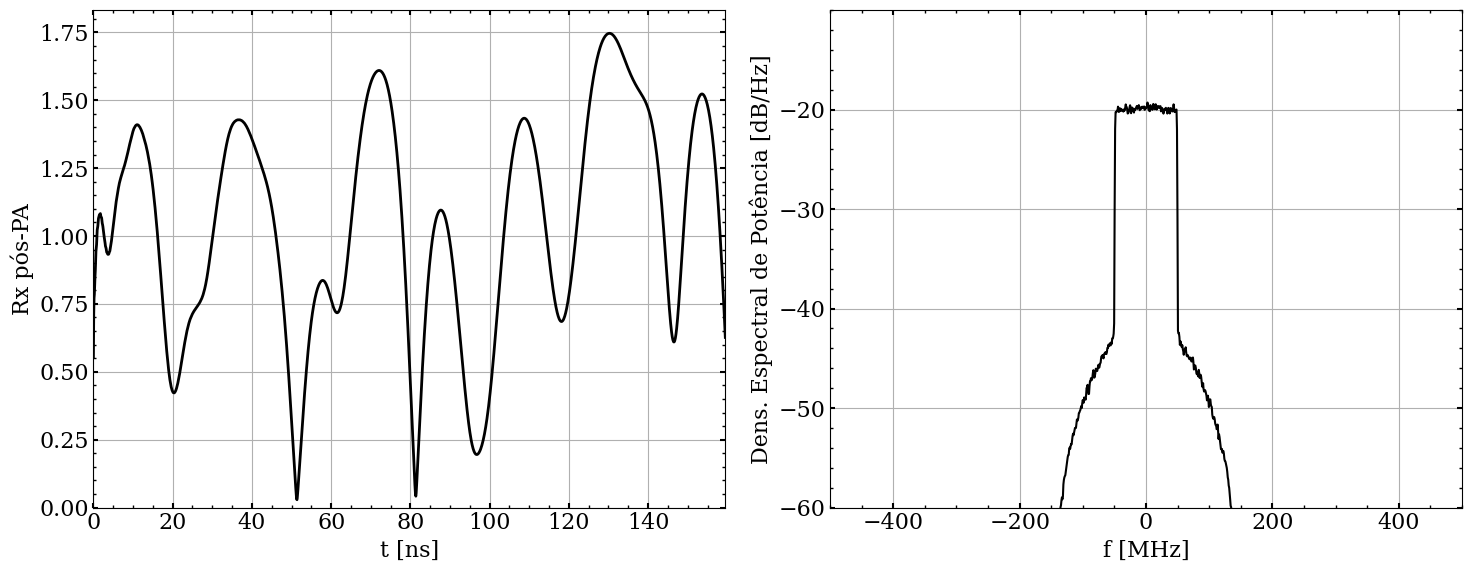

In [19]:

indx = np.arange(0, 2000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(sigRx_PA[indx]), "k", lw = 2)
axs[1].psd(sigRx_PA, Fs = Fs/1e6, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("Rx pós-PA")
axs[0].set_ylim(0)
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [MHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-500, 500)
axs[1].set_ylim(-60, -10)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-60, -10, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

In [20]:
delay = finddelay(sigRx, sigTx)
sigRx = np.roll(sigRx, -delay)

rot = np.mean(sigTx/sigRx)
sigRx = rot/np.abs(rot)*sigRx

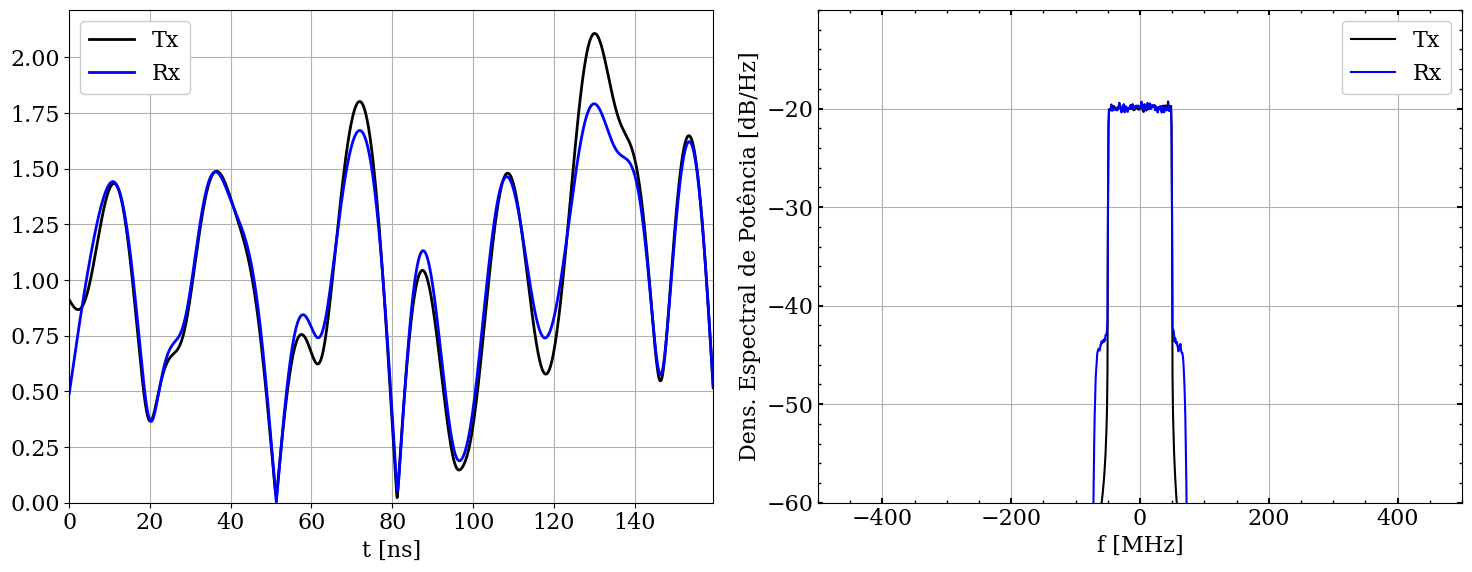

In [21]:

indx = np.arange(0, 2000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(pnorm(sigTx))[indx], label = "Tx", lw = 2, color = "k")
axs[0].plot(t[indx]*1e9, np.abs(pnorm(sigRx))[indx], label = "Rx", lw = 2, color = "b")

axs[1].psd(pnorm(sigTx), Fs = Fs/1e6, NFFT = 16*1024, sides = 'twosided', label = "Tx", color = "k")
axs[1].psd(pnorm(sigRx), Fs = Fs/1e6, NFFT = 16*1024, sides = 'twosided', label = "Rx", color = "b")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylim(0)
axs[0].grid()
axs[0].legend(framealpha = 1)

axs[1].set_xlabel("f [MHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-500, 500)
axs[1].set_ylim(-60, -10)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-60, -10, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1)

plt.tight_layout()
plt.show()

#### 2.6 Performance

In [22]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx, paramDec).ravel()
symbRx = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00579 
SNR = 20.554 dB
EVM = 9.128 %


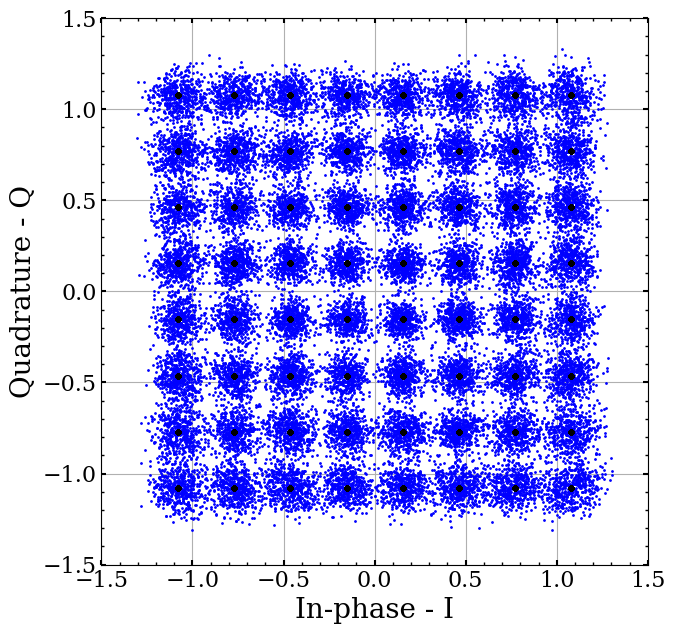

In [23]:
discard = Ni
index = np.arange(discard, symbTx.size - discard)
BER, SER, SNR = fastBERcalc(symbRx[index], symbTx[index], modOrder, modType)

EVM = np.sqrt(calcEVM(symbRx, modOrder, modType))*100

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB\nEVM = {EVM[0]:.3f} %")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx = pnorm(symbRx)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx.real, symbRx.imag, "o", color = "b", ms = 1, label = "SymbRx")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_ylabel("Quadrature - Q", fontsize = 20)
axs.set_xlabel("In-phase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-1.5, 1.5)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
plt.grid()

plt.tight_layout()
#plt.savefig("constelacao_noDPD.png")

SigTx - ACLR = -44.692 dB
SigRx PA w/o DPD - ACLR = -28.263 dB


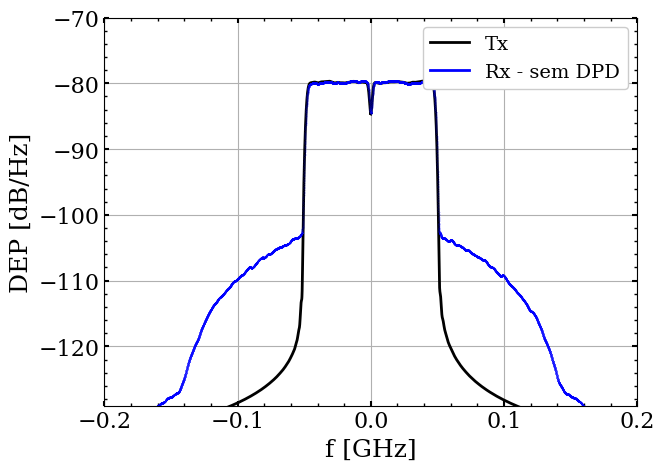

In [27]:
freq, P_sigTx    = welch(pnorm(sigTx)[0::SpS//4], fs = 4*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA = welch(pnorm(sigRx_PA)[0::SpS//4], fs = 4*Rs, nfft = 16*1024, return_onesided = False)

print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, paramOFDM.bw/2, 2.5e6):.3f} dB")
print(f"SigRx PA w/o DPD - ACLR = {calcACLR(P_sigRx_PA, freq, paramOFDM.bw/2, 2.5e6):.3f} dB")

fig, axs = plt.subplots(1, 1, figsize = (7, 5))

axs.plot(freq/1e9, 10*np.log10(P_sigTx), lw = 2, color = "k", label = "Tx")
axs.plot(freq/1e9, 10*np.log10(P_sigRx_PA), "o", lw = 2, color = "b", ms = 0.1)

# Trick to improve legends
axs.plot(1, 1, lw = 2, color = "b", label = "Rx - sem DPD")

axs.set_xlim(-0.2, 0.2)
axs.set_ylim(-129, -70)

axs.set_ylabel("DEP [dB/Hz]", fontsize = 18)
axs.set_xlabel("f [GHz]", fontsize = 18)
axs.legend(framealpha = 1, fontsize = 14, loc = "upper right")

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.grid()

plt.tight_layout()
#plt.savefig("sig_freq_mpDPD.pdf")

In [25]:
# Save params
np.savetxt(file_path + r"\transmittedSignal\symbTx.txt", symbTx, fmt = '%f')
np.savetxt(file_path + r"\transmittedSignal\symbRx.txt", symbRx, fmt = '%f')
np.savetxt(file_path + r"\transmittedSignal\sigTx.txt", sigTx, fmt = '%f')
np.savetxt(file_path + r"\transmittedSignal\sigRx_PA.txt", sigRx_PA, fmt = '%f')

paramOFDM.numOFDMframes = numOFDMframes
paramOFDM.modOrder = modOrder
paramOFDM.modType = modType
paramOFDM.Rs = Rs
paramOFDM.Fs = Fs
paramOFDM.gain_pre_MZM_PA = (gain_pre_MZM, gain_pre_PA)

with open(file_path + r'\transmittedSignal\paramOFDM.pkl', 'wb') as f:
    pickle.dump(paramOFDM, f)
    f.close()

with open(file_path + r'\transmittedSignal\paramMZM.pkl', 'wb') as f:
    pickle.dump(paramMZM, f)
    f.close()

with open(file_path + r'\transmittedSignal\paramChannel.pkl', 'wb') as f:
    pickle.dump(paramChannel, f)
    f.close()

with open(file_path + r'\transmittedSignal\paramRF.pkl', 'wb') as f:
    pickle.dump(paramRF, f)
    f.close()

with open(file_path + r'\transmittedSignal\paramPD.pkl', 'wb') as f:
    pickle.dump(paramPD, f)
    f.close()

In [26]:
with open('saved_dictionary.pkl', 'wb') as f:
    pickle.dump(paramOFDM, f)
    f.close()
    
with open('saved_dictionary.pkl', 'rb') as inp:
    company1 = pickle.load(inp)
    f.close()